对单个样本
𝑥
∈
𝑅
3
x∈R
3
  做二分类，网络结构如下：

输入层：3 个神经元

在这个练习里，为了方便你「手算 + 对比」最好给出一个确定的输入向量
𝑥
x，而不是每次都换一组随机数。

手动推导阶段，你直接选一个具体的数，比如

text
复制
编辑
x = [1.0,  2.0, -1.0]^T
这样每一步计算都能写得清晰、一致。

隐藏层：2 个神经元，激活函数 ReLU

𝑧
(
1
)
=
𝑊
1
𝑥
+
𝑏
1
,
𝑎
(
1
)
=
R
e
L
U
(
𝑧
(
1
)
)
z
(1)
 =W
1
​
 x+b
1
​
 ,a
(1)
 =ReLU(z
(1)
 )
其中

𝑊
1
=
[
0.2
−
0.4
0.1
0.5
0.2
−
0.3
]
,
𝑏
1
=
[
0.0
0.1
]
.
W
1
​
 =[
0.2
0.5
​
  
−0.4
0.2
​
  
0.1
−0.3
​
 ],b
1
​
 =[
0.0
0.1
​
 ].
输出层：2 个神经元，直接输出 logits

𝑧
(
2
)
=
𝑊
2

𝑎
(
1
)
+
𝑏
2
,
𝑝
^
=
s
o
f
t
m
a
x
(
𝑧
(
2
)
)
.
z
(2)
 =W
2
​
 a
(1)
 +b
2
​
 ,
p
^
​
 =softmax(z
(2)
 ).
其中

𝑊
2
=
[
−
0.3
0.8
0.7
−
0.2
]
,
𝑏
2
=
[
0.05
−
0.05
]
.
W
2
​
 =[
−0.3
0.7
​
  
0.8
−0.2
​
 ],b
2
​
 =[
0.05
−0.05
​
 ].
标签：目标类别
𝑦
t
r
u
e
=
1
y
true
​
 =1（第二类）。

要求
前向推导

计算隐藏层前激活
𝑧
(
1
)
z
(1)
  和激活输出
𝑎
(
1
)
a
(1)
 。

计算输出层 logits
𝑧
(
2
)
z
(2)
 、Softmax 概率
𝑝
^
p
^
​
 。

计算交叉熵损失

𝐿
=
−
ln
⁡
𝑝
^

𝑦
t
r
u
e
.
L=−ln
p
^
​
  
y
true
​

​
 .
反向推导
手动求出损失
𝐿
L 对
𝑊
2
,
𝑏
2
,
𝑊
1
,
𝑏
1
W
2
​
 ,b
2
​
 ,W
1
​
 ,b
1
​
  的梯度。

PyTorch 实现验证

用 nn.Linear 按上述权重、偏置初始化一个两层网络（注意要先 .detach().copy_() 或 .data.copy_()，避免警告）。

对同一个输入
𝑥
x 做一次前向和反向传播，打印出 layer1.weight.grad、layer1.bias.grad、layer2.weight.grad、layer2.bias.grad，验证它们是否与手动推导一致。





In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
#继承
class SimpleNN(nn.Module):
  def __init__(self, w1, w2, b1, b2):
    super().__init__()
    self.layer1 = nn.Linear(3, 2)
    self.output = nn.Linear(2, 2)

    self.layer1.weight.data.copy_(w1)
    self.layer1.bias.data.copy_(b1.flatten())

    self.output.weight.data.copy_(w2)
    self.output.bias.data.copy_(b2.flatten())

  def forward(self, x):
    x = torch.relu(self.layer1(x))
    x = self.output(self.output(x))

    return x

epoch:, 1 loss:, 0.2410
epoch:, 11 loss:, 0.1809
epoch:, 21 loss:, 0.1352
epoch:, 31 loss:, 0.1022
epoch:, 41 loss:, 0.0788
epoch:, 51 loss:, 0.0622
epoch:, 61 loss:, 0.0502
epoch:, 71 loss:, 0.0413
epoch:, 81 loss:, 0.0346
epoch:, 91 loss:, 0.0295
epoch:, 101 loss:, 0.0255
epoch:, 111 loss:, 0.0223
epoch:, 121 loss:, 0.0197
epoch:, 131 loss:, 0.0176
epoch:, 141 loss:, 0.0158
epoch:, 151 loss:, 0.0143
epoch:, 161 loss:, 0.0130
epoch:, 171 loss:, 0.0119
epoch:, 181 loss:, 0.0110
epoch:, 191 loss:, 0.0101
epoch:, 201 loss:, 0.0094
epoch:, 211 loss:, 0.0088
epoch:, 221 loss:, 0.0082
epoch:, 231 loss:, 0.0077
epoch:, 241 loss:, 0.0072
epoch:, 251 loss:, 0.0068
epoch:, 261 loss:, 0.0064
epoch:, 271 loss:, 0.0061
epoch:, 281 loss:, 0.0058
epoch:, 291 loss:, 0.0055
epoch:, 301 loss:, 0.0052
epoch:, 311 loss:, 0.0050
epoch:, 321 loss:, 0.0048
epoch:, 331 loss:, 0.0046
epoch:, 341 loss:, 0.0044
epoch:, 351 loss:, 0.0042
epoch:, 361 loss:, 0.0040
epoch:, 371 loss:, 0.0039
epoch:, 381 loss:, 0.00

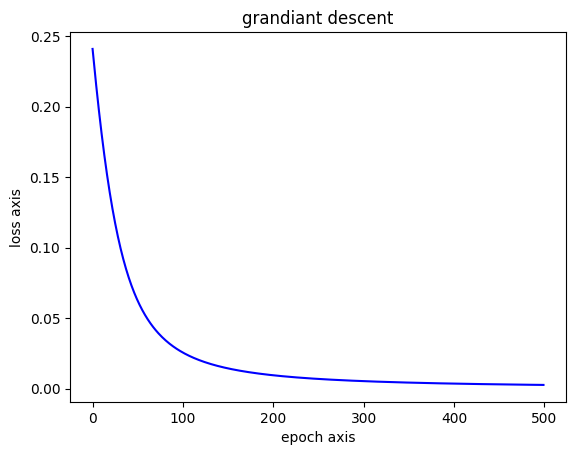

In [4]:
#初始化参数
x = torch.tensor([[1.0, 2.0, -1.0]]).to(device)

w1 = torch.tensor([[0.2, -0.4, 0.1],
          [0.5, 0.2, -0.3]]).to(device)

b1 = torch.tensor([[0.0],
          [0.1]]).to(device)

w2 = torch.tensor([[-0.3, 0.8],
          [0.7, -0.2]]).to(device)

b2 = torch.tensor([[0.05],
          [-0.05]]).to(device)

y_true = torch.tensor([0, 1]).to(device)
y_true_index = torch.tensor([1]).to(device)

model = SimpleNN(w1, w2, b1, b2).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

losses = []
epochs = 500

for epoch in range(epochs):
  y_pred = model(x)

  loss = criterion(y_pred, y_true_index)
  losses.append(loss.item())

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  if epoch % 10 ==0:
    print(f"epoch:, {epoch+1}",
       f"loss:, {loss.item():.4f}")

with torch.no_grad():
  y_pred = torch.softmax(model(x), dim=1)

print("the real value is:")
print(y_true)

print("the predication value is:")
print(y_pred)

y_pred_index = torch.argmax(y_pred, dim=1)
print("the y_pred index is:")
print(y_pred_index)

print("the y_true index is:")
print(y_true_index)

plt.plot(range(epochs), losses, "blue")
plt.xlabel("epoch axis")
plt.ylabel("loss axis")
plt.title("grandiant descent")
plt.show()